# 4장 1강 프로젝트 개요와 문제 정의

## 실습 목표

- Ravenstack의 5개 테이블을 탐색하고 분석 단위와 연결 키를 설명한다.
- 데이터 품질과 기초 분포를 확인하여 분석 가능한 근거를 만든다.
- EDA 결과를 바탕으로 측정 가능한 문제, 목표 지표, 초기 가설을 정의한다.
- 이후 강의에서 검증할 분석 흐름을 일관되게 설계한다.

## 실습 환경 / 데이터

- Python / Colab, `pandas`, `matplotlib`
- `ravenstack_accounts.csv`: 계정 속성과 계정 이탈 여부
- `ravenstack_subscriptions.csv`: 구독 이력과 MRR, 플랜, 이탈 여부
- `ravenstack_feature_usage.csv`: 기능별 사용량과 오류
- `ravenstack_support_tickets.csv`: 문의 처리와 만족도
- `ravenstack_churn_events.csv`: 이탈 사유와 환불

> 분석 기준: 계정의 대표 이탈 지표는 `accounts.churn_flag`로 정의합니다. 서로 다른 테이블의 같은 이름 컬럼을 임의로 섞지 않습니다.

## 실습 준비

### 데이터 불러오기

> 풀이 데이터: 이 폴더의 `data/` CSV. RavenStack은 River @ Rivalytics의 합성 교육용 데이터다. 실제 사업 성과로 일반화하지 않는다.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")

file_names = {
    "accounts": "ravenstack_accounts.csv",
    "subscriptions": "ravenstack_subscriptions.csv",
    "feature_usage": "ravenstack_feature_usage.csv",
    "support_tickets": "ravenstack_support_tickets.csv",
    "churn_events": "ravenstack_churn_events.csv",
}

candidate_dirs = [Path("data"), Path("."), Path("upload"), Path("/content")]
data_dir = next((d for d in candidate_dirs if all((d / f).exists() for f in file_names.values())), None)
if data_dir is None:
    raise FileNotFoundError("5개 CSV를 노트북과 같은 폴더(또는 /content)에 업로드해 주세요.")

data = {name: pd.read_csv(data_dir / file) for name, file in file_names.items()}
accounts = data["accounts"]
subscriptions = data["subscriptions"]
feature_usage = data["feature_usage"]
support_tickets = data["support_tickets"]
churn_events = data["churn_events"]

print("데이터 폴더:", data_dir.resolve())
for name, df in data.items():
    print(f"{name:16s}: {df.shape[0]:,}행 × {df.shape[1]}열")

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from matplotlib import font_manager
if 'Malgun Gothic' in {f.name for f in font_manager.fontManager.ttflist}:
    plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams.update({'axes.unicode_minus': False, 'figure.figsize': (8,4), 'font.size': 11})
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_rows', 30)
def show_rates(frame):
    display(frame.style.format({c: '{:.2%}' for c in frame.columns if 'rate' in str(c) or 'conversion' in str(c)}, na_rep='—'))
def bars(series, title, ylabel, percent=False):
    ax = (series * (100 if percent else 1)).plot.bar(color='#32689b', rot=0)
    ax.set(title=title, ylabel=ylabel, xlabel='')
    ax.set_ylim(bottom=0)
    plt.tight_layout(); plt.show()
def make_funnel(counts, labels):
    f = pd.DataFrame({'count': counts}, index=labels)
    prev = f['count'].shift().replace(0, np.nan)
    f['conversion_rate'] = f['count'] / prev
    f['drop_rate'] = 1 - f.conversion_rate
    f['drop_count'] = f['count'].shift() - f['count']
    return f


데이터 폴더: C:\Projects\01_Lecture_Study\product_2\data
accounts        : 500행 × 10열
subscriptions   : 5,000행 × 14열
feature_usage   : 25,000행 × 8열
support_tickets : 2,000행 × 9열
churn_events    : 600행 × 9열


### 분석 대상 컬럼 확인

각 테이블의 앞부분과 컬럼을 확인하세요.

In [2]:
for name, df in data.items():
    print(f"\n[{name}] 컬럼")
    print(df.columns.tolist())
    display(df.head(2))


[accounts] 컬럼
['account_id', 'account_name', 'industry', 'country', 'signup_date', 'referral_source', 'plan_tier', 'seats', 'is_trial', 'churn_flag']


,account_id,account_name,industry,country,signup_date,referral_source,plan_tier,seats,is_trial,churn_flag
0,A-2e4581,Company_0,EdTech,US,2024-10-16,partner,Basic,9,False,False
1,A-43a9e3,Company_1,FinTech,IN,2023-08-17,other,Basic,18,False,True



[subscriptions] 컬럼
['subscription_id', 'account_id', 'start_date', 'end_date', 'plan_tier', 'seats', 'mrr_amount', 'arr_amount', 'is_trial', 'upgrade_flag', 'downgrade_flag', 'churn_flag', 'billing_frequency', 'auto_renew_flag']


,subscription_id,account_id,start_date,end_date,plan_tier,seats,mrr_amount,arr_amount,is_trial,upgrade_flag,downgrade_flag,churn_flag,billing_frequency,auto_renew_flag
0,S-8cec59,A-3c1a3f,2023-12-23,2024-04-12,Enterprise,14,2786,33432,False,False,False,True,monthly,True
1,S-0f6f44,A-9b9fe9,2024-06-11,NaN,Pro,17,833,9996,False,False,False,False,monthly,True



[feature_usage] 컬럼
['usage_id', 'subscription_id', 'usage_date', 'feature_name', 'usage_count', 'usage_duration_secs', 'error_count', 'is_beta_feature']


,usage_id,subscription_id,usage_date,feature_name,usage_count,usage_duration_secs,error_count,is_beta_feature
0,U-1c6c24,S-0fcf7d,2023-07-27,feature_20,9,5004,0,False
1,U-f07cb8,S-c25263,2023-08-07,feature_5,9,369,0,False



[support_tickets] 컬럼
['ticket_id', 'account_id', 'submitted_at', 'closed_at', 'resolution_time_hours', 'priority', 'first_response_time_minutes', 'satisfaction_score', 'escalation_flag']


,ticket_id,account_id,submitted_at,closed_at,resolution_time_hours,priority,first_response_time_minutes,satisfaction_score,escalation_flag
0,T-0024de,A-712f1c,2023-07-27,2023-07-28 03:00:00,27.0,high,74,NaN,False
1,T-4d04b9,A-e43bf7,2024-07-08,2024-07-09 03:00:00,27.0,urgent,144,NaN,False



[churn_events] 컬럼
['churn_event_id', 'account_id', 'churn_date', 'reason_code', 'refund_amount_usd', 'preceding_upgrade_flag', 'preceding_downgrade_flag', 'is_reactivation', 'feedback_text']


,churn_event_id,account_id,churn_date,reason_code,refund_amount_usd,preceding_upgrade_flag,preceding_downgrade_flag,is_reactivation,feedback_text
0,C-816288,A-c37cab,2024-10-27,pricing,4.03,False,False,False,switched to competitor
1,C-5a81e7,A-37f969,2024-06-25,support,96.45,True,False,False,NaN


### 결측치 및 자료형 확인

날짜 컬럼을 변환하고 키 중복을 확인합니다.

In [3]:
# 날짜 컬럼을 datetime으로 변환합니다.
date_columns = {
    "accounts": ["signup_date"],
    "subscriptions": ["start_date", "end_date"],
    "feature_usage": ["usage_date"],
    "support_tickets": ["submitted_at", "closed_at"],
    "churn_events": ["churn_date"],
}
for name, columns in date_columns.items():
    for column in columns:
        data[name][column] = pd.to_datetime(data[name][column], errors="coerce")

# 분석 단위와 키를 확인합니다.
key_columns = {
    "accounts": "account_id",
    "subscriptions": "subscription_id",
    "feature_usage": "usage_id",
    "support_tickets": "ticket_id",
    "churn_events": "churn_event_id",
}
for name, key in key_columns.items():
    df = data[name]
    print(f"{name:16s} | key 중복 {df[key].duplicated().sum():>2} | 전체 행 중복 {df.duplicated().sum():>2}")

accounts         | key 중복  0 | 전체 행 중복  0
subscriptions    | key 중복  0 | 전체 행 중복  0
feature_usage    | key 중복 21 | 전체 행 중복  0
support_tickets  | key 중복  0 | 전체 행 중복  0
churn_events     | key 중복  0 | 전체 행 중복  0


### 기초 통계량과 분포 확인

아래 코드로 수치형 변수와 주요 범주의 분포를 확인하세요.

In [4]:
display(accounts[["seats", "churn_flag"]].describe())
display(accounts["plan_tier"].value_counts().rename("accounts"))
display(churn_events["reason_code"].value_counts().rename("events"))

,seats
count,500.000000
mean,20.560000
std,21.044718
min,1.000000
25%,5.000000
50%,15.000000
75%,28.000000
max,163.000000


plan_tier
Pro           178
Basic         168
Enterprise    154
Name: accounts, dtype: int64

reason_code
features      114
support       104
budget        104
unknown        95
competitor     92
pricing        91
Name: events, dtype: int64

---

## 필수 1 — 5개 테이블의 EDA 요약

각 테이블에 대해 다음 항목을 하나의 요약표로 만드세요.

1. 행 수와 열 수
2. 전체 결측치 수
3. 완전히 동일한 중복 행 수
4. 날짜 범위(최솟값~최댓값)

그 후 다음 질문에 답하세요.

- 결측치가 있는 테이블과 컬럼은 무엇인가요?
- 결측치를 곧바로 삭제하면 안 되는 이유는 무엇인가요?
- 분석 전에 주의할 데이터 품질 문제를 한 가지 쓰세요.

In [5]:
summary_rows=[]
for name,df in data.items():
    ranges='; '.join(f'{col}: {df[col].min()} ~ {df[col].max()}' for col in date_columns[name])
    summary_rows.append({'table':name,'rows':len(df),'columns':len(df.columns),'missing':int(df.isna().sum().sum()),'duplicates':int(df.duplicated().sum()),'date_range':ranges})
    display(pd.DataFrame({'dtype':df.dtypes.astype(str),'missing':df.isna().sum()}))
eda_summary=pd.DataFrame(summary_rows)
display(eda_summary)
print('결측 컬럼:', {k:v.isna().sum()[v.isna().any()].to_dict() for k,v in data.items()})
assert accounts.account_id.is_unique and subscriptions.subscription_id.is_unique
assert subscriptions.account_id.isin(accounts.account_id).all()
assert feature_usage.subscription_id.isin(subscriptions.subscription_id).all()
print('종료일 결측은 미종료 상태일 수 있고 만족도·피드백 결측은 무응답이므로 일괄 삭제하면 모집단이 바뀐다.')
print('합성 데이터에서도 구독 시작/종료와 사용 시각의 일치 여부를 별도로 점검해야 한다.')

,dtype,missing
account_id,object,0
account_name,object,0
industry,object,0
country,object,0
signup_date,datetime64[ns],0
referral_source,object,0
plan_tier,object,0
seats,int64,0
is_trial,bool,0
churn_flag,bool,0


,dtype,missing
subscription_id,object,0
account_id,object,0
start_date,datetime64[ns],0
end_date,datetime64[ns],4514
plan_tier,object,0
seats,int64,0
mrr_amount,int64,0
arr_amount,int64,0
is_trial,bool,0
upgrade_flag,bool,0


,dtype,missing
usage_id,object,0
subscription_id,object,0
usage_date,datetime64[ns],0
feature_name,object,0
usage_count,int64,0
usage_duration_secs,int64,0
error_count,int64,0
is_beta_feature,bool,0


,dtype,missing
ticket_id,object,0
account_id,object,0
submitted_at,datetime64[ns],0
closed_at,datetime64[ns],0
resolution_time_hours,float64,0
priority,object,0
first_response_time_minutes,int64,0
satisfaction_score,float64,825
escalation_flag,bool,0


,dtype,missing
churn_event_id,object,0
account_id,object,0
churn_date,datetime64[ns],0
reason_code,object,0
refund_amount_usd,float64,0
preceding_upgrade_flag,bool,0
preceding_downgrade_flag,bool,0
is_reactivation,bool,0
feedback_text,object,148


,table,rows,columns,missing,duplicates,date_range
0,accounts,500,10,0,0,signup_date: 2023-01-02 00:00:00 ~ 2024-12-31 ...
1,subscriptions,5000,14,4514,0,start_date: 2023-01-09 00:00:00 ~ 2024-12-31 0...
2,feature_usage,25000,8,0,0,usage_date: 2023-01-01 00:00:00 ~ 2024-12-31 0...
3,support_tickets,2000,9,825,0,submitted_at: 2023-01-02 00:00:00 ~ 2024-12-31...
4,churn_events,600,9,148,0,churn_date: 2023-01-25 00:00:00 ~ 2024-12-31 0...


결측 컬럼: {'accounts': {}, 'subscriptions': {'end_date': 4514}, 'feature_usage': {}, 'support_tickets': {'satisfaction_score': 825}, 'churn_events': {'feedback_text': 148}}
종료일 결측은 미종료 상태일 수 있고 만족도·피드백 결측은 무응답이므로 일괄 삭제하면 모집단이 바뀐다.
합성 데이터에서도 구독 시작/종료와 사용 시각의 일치 여부를 별도로 점검해야 한다.


---

## 필수 2 — 근거를 연결해 분석 문제 정의하기

계정 테이블을 기준으로 다음을 분석하세요.

1. 전체 계정 이탈률을 계산하세요.
2. `industry`, `referral_source`, `is_trial`별 계정 수와 이탈률을 계산하세요.
3. 표본이 20개 이상인 세그먼트 중 전체 이탈률보다 높은 구간을 찾으세요.
4. 결과를 근거로 **문제 정의 1문장**, **현재 지표**, **목표 지표**를 작성하세요.
5. 이탈률이 가장 높은 산업군을 막대그래프로 비교하세요.

> 목표값은 정답이 하나가 아닙니다. 현재 값보다 개선된 수치이며, 지표·대상·기간(또는 평가 시점)이 드러나게 작성하세요.

전체 계정 이탈 비율: 22.00%
industry


,accounts,churned,churn_rate
industry,,,
DevTools,113,35,30.97%
FinTech,112,25,22.32%
HealthTech,96,21,21.88%
EdTech,79,13,16.46%
Cybersecurity,100,16,16.00%


표본 20개 이상이며 전체보다 높은 구간


,accounts,churned,churn_rate
industry,,,
DevTools,113,35,30.97%
FinTech,112,25,22.32%


referral_source


...

,accounts,churned,churn_rate
referral_source,,,
event,96,29,30.21%
other,103,25,24.27%
ads,98,23,23.47%


is_trial


,accounts,churned,churn_rate
is_trial,,,
True,97,25,25.77%
False,403,85,21.09%


표본 20개 이상이며 전체보다 높은 구간


,accounts,churned,churn_rate
is_trial,,,
True,97,25,25.77%


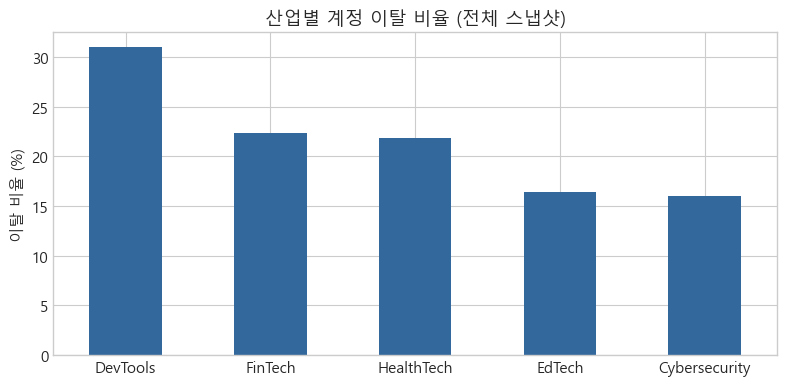

In [6]:
overall_churn_rate=accounts.churn_flag.mean()
segment_results={}
print(f'전체 계정 이탈 비율: {overall_churn_rate:.2%}')
for column in ['industry','referral_source','is_trial']:
    result=accounts.groupby(column).agg(accounts=('account_id','nunique'),churned=('churn_flag','sum'),churn_rate=('churn_flag','mean')).sort_values('churn_rate',ascending=False)
    segment_results[column]=result
    print(column); show_rates(result)
    print('표본 20개 이상이며 전체보다 높은 구간'); show_rates(result.loc[(result.accounts>=20)&(result.churn_rate>overall_churn_rate)])
industry_metrics=segment_results['industry']
bars(industry_metrics.churn_rate,'산업별 계정 이탈 비율 (전체 스냅샷)','이탈 비율 (%)',True)
priority_industry=industry_metrics.loc[industry_metrics.accounts>=20].churn_rate.idxmax()

### 필수 2 서술 답안
- 발견한 핵심 패턴: 전체 이탈 비율 22.00%, 표본 20개 이상 산업 중 DevTools의 비율이 30.97%로 가장 높다 (n=113).
- 문제 정의: DevTools 계정의 높은 누적 이탈 비율을 단서로 초기 사용과 지원 경험의 개선 가능성을 조사한다.
- 현재 지표: 위 수치는 전체 스냅샷의 과거 이탈 경험 비율이며 기간별 신규 이탈률이 아니다.
- 목표 지표: 다음 분기 시작 시 활성인 해당 산업 계정을 고정 모집단으로 두고 90일 내 신규 이탈 비율을 대조군 대비 5%p 낮춘다(기획 목표).
- 적절한 이유: 과거 churn_flag는 되돌릴 수 없어 누적 비율 감소를 성공 기준으로 삼지 않는다. 동일한 대상·기간의 신규 이탈로 미래 개선을 평가한다. 5%p는 관측 성과가 아니라 사전에 검토할 가정이다.

## 과제 1 — 이탈 원인 가설과 검증 계획

| 우선순위 | 가설 | 필요한 데이터 | 검증 방법 |
|---|---|---|---|
| 1 | 초기 기능 사용이 적은 계정은 후속 이탈이 많다 | accounts.signup_date/industry, subscriptions.account_id/subscription_id, feature_usage.usage_date/usage_count, churn_events.churn_date | 가입 후 30일 사용량별 이후 90일 이탈 비교, 관찰 기간 확보, 이탈 이후 행동 제외 |
| 2 | 지원 해결이 느린 계정은 이후 이탈이 많다 | support_tickets.account_id/submitted_at/resolution_time_hours, churn_events.account_id/churn_date | 이탈 전 문의만 사용, 산업·규모·가입 시점을 맞춰 해결 시간별 후속 이탈 비교 |
| 3 | 실제 업무와 온보딩 안내가 맞지 않아 이탈한다 | 신규 설문·인터뷰, 안내 노출 로그 추가 수집 | 목표 산업의 신규 계정을 기존/산업별 안내로 무작위 배정 후 활성률·90일 이탈 비교 |

가설 1은 기존 데이터의 기능 행동으로 개선 지점을 좁힐 수 있어 먼저 검증한다. 가설 1·2는 현재 데이터로 연관성을 점검할 수 있지만 관찰 비교만으로 원인을 확정하지 않는다.

- 2강 분석: 동일한 산업·계정 단위로 퍼널과 코호트 리텐션을 비교해 미도달 구간을 찾는다.
- 3강 실험: 해당 구간의 안내 변경을 계정 단위로 무작위 배정해 가설을 검증한다.
- 4강 제안: 목표 지표·지원 부담·개발 비용을 함께 비교해 실행 여부와 후속 모니터링을 제안한다.

---

## 실습 마무리

- 어떤 분석 문제가 있었는가?
- 어떤 통계적·분석적 방법을 적용했는가?
- 무엇을 근거로 결론을 내렸는가?

### 마무리 답변
- 산업별 높은 계정 이탈 비율의 개선 가능성을 문제로 정했다.
- EDA와 표본 20개 이상 세그먼트의 이탈 비율 비교를 적용했다.
- 실제 집계표로 점검 대상을 선정했으며, 원인과 개선 효과는 후속 분석·실험으로 검증한다.